### N-gram language models or how to write scientific papers (4 pts)

We shall train our language model on a corpora of [ArXiv](http://arxiv.org/) articles and see if we can generate a new one!

![img](https://media.npr.org/assets/img/2013/12/10/istock-18586699-monkey-computer_brick-16e5064d3378a14e0e4c2da08857efe03c04695e-s800-c85.jpg)

_data by neelshah18 from [here](https://www.kaggle.com/neelshah18/arxivdataset/)_

_Disclaimer: this has nothing to do with actual science. But it's fun, so who cares?!_

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Alternative manual download link: https://yadi.sk/d/_nGyU2IajjR9-w
# !wget "https://www.dropbox.com/s/99az9n1b57qkd9j/arxivData.json.tar.gz?dl=1" -O arxivData.json.tar.gz
# !tar -xvzf arxivData.json.tar.gz
# data = pd.read_json("./arxivData.json")
data = pd.read_json(r"E:\01_Datasets\arxivData.json")
data.sample(n=5)

,author,day,id,link,month,summary,tag,title,year
21345,[{'name': 'Fabricio Olivetti de Franca'}],4,1801.01807v1,"[{'rel': 'related', 'href': 'http://dx.doi.org...",1,Symbolic Regression tries to find a mathematic...,"[{'term': 'cs.AI', 'scheme': 'http://arxiv.org...",A Greedy Search Tree Heuristic for Symbolic Re...,2018
35496,"[{'name': 'Kevin Henshall'}, {'name': 'Peter S...",1,0804.0066v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",4,Selman and Kautz's work on ``knowledge compila...,"[{'term': 'cs.LO', 'scheme': 'http://arxiv.org...",Binary Decision Diagrams for Affine Approximation,2008
28982,"[{'name': 'Anoop Cherian'}, {'name': 'Panagiot...",5,1708.01741v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",8,Symmetric positive definite (SPD) matrices are...,"[{'term': 'cs.CV', 'scheme': 'http://arxiv.org...",Learning Discriminative Alpha-Beta-divergence ...,2017
2339,"[{'name': 'Ryan A. Rossi'}, {'name': 'Luke K. ...",30,1204.0033v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",3,Relational data representations have become an...,"[{'term': 'stat.ML', 'scheme': 'http://arxiv.o...",Transforming Graph Representations for Statist...,2012
12651,"[{'name': 'Po-Yu Chen'}, {'name': 'Ivan W. Sel...",29,1304.0035v1,"[{'rel': 'related', 'href': 'http://dx.doi.org...",3,This paper addresses signal denoising when lar...,"[{'term': 'cs.CV', 'scheme': 'http://arxiv.org...",Translation-Invariant Shrinkage/Thresholding o...,2013


In [3]:
# assemble lines: concatenate title and description
lines = data.apply(lambda row: row['title'] + ' ; ' + row['summary'].replace("\n", ' '), axis=1).tolist()
# apply sẽ chạy từng dòng áp dụng lambda định nghĩa, axis =1 -> duyệt theo từng cột, sau khi apply trả về kiểu series nên chuyển về lại list

sorted(lines, key=len)[:3] # độ dài chuỗi làm tiêu chí sắp xếp , sau đó lấy ra 3 cái thôi

['Differential Contrastive Divergence ; This paper has been retracted.',
 'What Does Artificial Life Tell Us About Death? ; Short philosophical essay',
 'P=NP ; We claim to resolve the P=?NP problem via a formal argument for P=NP.']

In [4]:
# lambda trên tương đương với:
def create_line(row):
    return row['title'] + ' ; ' + row['summary'].replace("\n", ' ')

### Tokenization

You know the dril. The data is messy. Go clean the data. Use WordPunctTokenizer or something.


In [5]:
# Task: convert lines (in-place) into strings of space-separated tokens. Import & use WordPunctTokenizer

from nltk.tokenize import WordPunctTokenizer # module để tách dấu các câu

# Khởi tạo tokenizer
tokenizer = WordPunctTokenizer()

# Token hóa từng dòng, chuyển đổi thành chữ thường (lower) để khớp với assert, 
# sau đó nối các tokens lại bằng khoảng trắng (space-separated)
lines = [' '.join(tokenizer.tokenize(line.lower())) for line in lines] # join lại bẳng khoảng trắng, nghĩa là chuẩn hóa các trường hợp đặt dấu câu sai

In [6]:
assert sorted(lines, key=len)[0] == \
    'differential contrastive divergence ; this paper has been retracted .'
assert sorted(lines, key=len)[2] == \
    'p = np ; we claim to resolve the p =? np problem via a formal argument for p = np .'

### N-Gram Language Model (1 point)

A language model is a probabilistic model that estimates text probability: the joint probability of all tokens $w_t$ in text $X$:

$$
P(X) = P(w_1, \dots, w_T).
$$

It can do so by following the chain rule:

$$
P(w_1, \dots, w_T)
=
P(w_1)
P(w_2 \mid w_1)
\dots
P(w_T \mid w_1, \dots, w_{T-1}).
$$

The problem with such approach is that the final term

$$
P(w_T \mid w_1, \dots, w_{T-1})
$$

depends on $T - 1$ previous words. This probability is impractical to estimate for long texts, e.g. $T = 1000$.

One popular approximation is to assume that next word only depends on a finite amount of previous words:

$$
P(w_t \mid w_1, \dots, w_{t-1})
=
P(w_t \mid w_{t-n+1}, \dots, w_{t-1})
$$

Such model is called **n-gram language model** where $n$ is a parameter. For example, in a 3-gram language model, each word only depends on 2 previous words.

$$
P(w_1, \dots, w_T)
=
\prod_t P(w_t \mid w_{t-n+1}, \dots, w_{t-1}).
$$

You can also sometimes see such approximation under the name of *n-th order Markov assumption*.

The first stage to building such a model is counting all word occurences given N-1 previous words

In [7]:
from tqdm import tqdm
from collections import defaultdict, Counter

# special tokens: 
# - `UNK` represents absent tokens, 
# - `EOS` is a special token after the end of sequence

UNK, EOS = "_UNK_", "_EOS_"

def count_ngrams(lines, n):
    """
    Count how many times each word occured after (n - 1) previous words
    :param lines: an iterable of strings with space-separated tokens
    :returns: a dictionary { tuple(prefix_tokens): {next_token_1: count_1, next_token_2: count_2}}

    When building counts, please consider the following two edge cases:
    - if prefix is shorter than (n - 1) tokens, it should be padded with UNK. For n=3,
      empty prefix: "" -> (UNK, UNK)
      short prefix: "the" -> (UNK, the)
      long prefix: "the new approach" -> (new, approach)
    - you should add a special token, EOS, at the end of each sequence
      "... with deep neural networks ." -> (..., with, deep, neural, networks, ., EOS)
      count the probability of this token just like all others.
    """
    counts = defaultdict(Counter)
    # counts[(word1, word2)][word3] = how many times word3 occured after (word1, word2)

    for line in lines:
        # Tách chuỗi thành các token và thêm token kết thúc EOS vào cuối
        tokens = line.split() + [EOS]
        
        # Đệm (n - 1) token UNK vào đầu để xử lý các prefix ngắn
        padded_tokens = [UNK] * (n - 1) + tokens
        
        # Dùng cửa sổ trượt (sliding window) độ dài n để đếm
        for i in range(len(padded_tokens) - n + 1):
            # Lấy (n - 1) từ làm prefix và chuyển thành tuple (để có thể làm key cho dictionary)
            prefix = tuple(padded_tokens[i : i + n - 1])
            # Từ tiếp theo (từ thứ n)
            next_token = padded_tokens[i + n - 1]
            
            # Tăng biến đếm
            counts[prefix][next_token] += 1 # prefix là context, next_token là target word, khi sử dụng lấy ra context suy luận target 
            
    return counts

In [8]:
# vd: kết quả trả về của counts
# {
#     ('I', 'love'): {
#         'AI': 25,
#         'Python': 5
#     }
# }

In [9]:
# let's test it
dummy_lines = sorted(lines, key=len)[:100]
dummy_counts = count_ngrams(dummy_lines, n=3)
assert set(map(len, dummy_counts.keys())) == {2}, "please only count {n-1}-grams"
assert len(dummy_counts[('_UNK_', '_UNK_')]) == 78
assert dummy_counts['_UNK_', 'a']['note'] == 3
assert dummy_counts['p', '=']['np'] == 2
assert dummy_counts['author', '.']['_EOS_'] == 1

Once we can count N-grams, we can build a probabilistic language model.
The simplest way to compute probabilities is in proporiton to counts:

$$ P(w_t | prefix) = { Count(prefix, w_t) \over \sum_{\hat w} Count(prefix, \hat w) } $$

PHần mẫu ở dưới là tổng tất cả count của prefix đang xét, có cả wt cùng với các w khác 

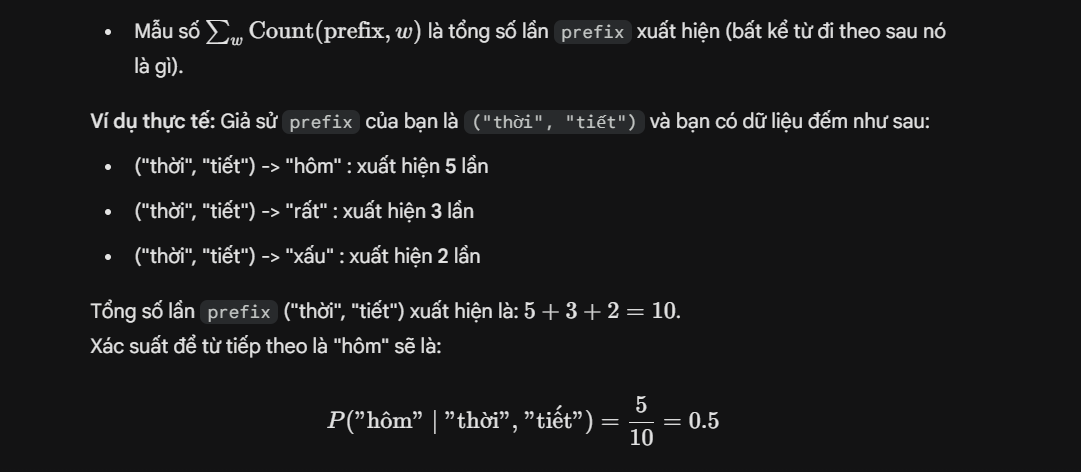

In [10]:
class NGramLanguageModel:    
    def __init__(self, lines, n): # khi tạo instance sẽ gọi đến, self là instance đó 
        """ 
        Train a simple count-based language model: 
        compute probabilities P(w_t | prefix) given ngram counts
        
        :param n: computes probability of next token given (n - 1) previous words
        :param lines: an iterable of strings with space-separated tokens
        """
        assert n >= 1
        self.n = n
    
        counts = count_ngrams(lines, self.n)
        
        # compute token proabilities given counts
        self.probs = defaultdict(Counter)
        # probs[(word1, word2)][word3] = P(word3 | word1, word2)
        
        # populate self.probs with actual probabilities
        for prefix, next_token_counts in counts.items():
            # Tính tổng số lần xuất hiện của tất cả các từ đi sau prefix này
            total_count = sum(next_token_counts.values())
            
            # Tính xác suất cho từng từ và lưu vào self.probs
            for next_token, count in next_token_counts.items():
                self.probs[prefix][next_token] = count / total_count
            
    def get_possible_next_tokens(self, prefix):
        """
        :param prefix: string with space-separated prefix tokens
        :returns: a dictionary {token : it's probability} for all tokens with positive probabilities
        """
        prefix = prefix.split()
        prefix = prefix[max(0, len(prefix) - self.n + 1):] # Lấy đúng (n−1) token cuối, nếu không đủ n-1 thì code dưới sẽ thêm UNK
        prefix = [ UNK ] * (self.n - 1 - len(prefix)) + prefix
        return self.probs[tuple(prefix)] # Vì dictionary key phải là immutable để làm key được. còn array thì không 
    # hàm trả về probs là target word tương ứng context prefix đó, là danh sách các từ với xs khác nhau
    
    def get_next_token_prob(self, prefix, next_token):
        """
        :param prefix: string with space-separated prefix tokens
        :param next_token: the next token to predict probability for
        :returns: P(next_token|prefix) a single number, 0 <= P <= 1
        """
        return self.get_possible_next_tokens(prefix).get(next_token, 0) # tương đương dict.get(key, default)

Let's test it!

In [11]:
dummy_lm = NGramLanguageModel(dummy_lines, n=3)

p_initial = dummy_lm.get_possible_next_tokens('') # '' -> ['_UNK_', '_UNK_']
assert np.allclose(p_initial['learning'], 0.02)
assert np.allclose(p_initial['a'], 0.13)
assert np.allclose(p_initial.get('meow', 0), 0)
assert np.allclose(sum(p_initial.values()), 1)

p_a = dummy_lm.get_possible_next_tokens('a') # '' -> ['_UNK_', 'a']
assert np.allclose(p_a['machine'], 0.15384615)
assert np.allclose(p_a['note'], 0.23076923)
assert np.allclose(p_a.get('the', 0), 0)
assert np.allclose(sum(p_a.values()), 1)

assert np.allclose(dummy_lm.get_possible_next_tokens('a note')['on'], 1)
assert dummy_lm.get_possible_next_tokens('a machine') == \
    dummy_lm.get_possible_next_tokens("there have always been ghosts in a machine"), \
    "your 3-gram model should only depend on 2 previous words"

Now that you've got a working n-gram language model, let's see what sequences it can generate. But first, let's train it on the whole dataset.

In [12]:
lm = NGramLanguageModel(lines, n=3)

The process of generating sequences is... well, it's sequential. You maintain a list of tokens and iteratively add next token by sampling with probabilities.

$ X = [] $

__forever:__
* $w_{next} \sim P(w_{next} | X)$
* $X = concat(X, w_{next})$


Instead of sampling with probabilities, one can also try always taking most likely token, sampling among top-K most likely tokens or sampling with temperature. In the latter case (temperature), one samples from

$$w_{next} \sim {P(w_{next} | X) ^ {1 / \tau} \over \sum_{\hat w} P(\hat w | X) ^ {1 / \tau}}$$

Where $\tau > 0$ is model temperature. If $\tau << 1$, more likely tokens will be sampled with even higher probability while less likely tokens will vanish.

T nhiệt độ này < 1 thì sẽ tăng xác suất các từ phổ biến được bắt 

càng giảm thì các xác suất càng xa nhau nhau nhất -> sự thay đổi xác suất rõ rệt khiến chọn đúng từ có xs cao hơn

Càng tăng thì xác suất các từ gần nhau hơn -> sự thay đổi càng mờ hơn khiến các từ khó chọn có xác suất dễ chọn hơn 

| Temperature | Hiệu ứng | Phân phối              | Kết quả sinh văn bản             |
| ----------- | -------- | ---------------------- | -------------------------------- |
| 0           | Greedy   | Chỉ lấy token lớn nhất | Rất ổn định, ít sáng tạo         |
| 0.1         | Rất thấp | Rất nhọn (sharp)       | Gần như luôn chọn token tốt nhất |
| 0.5         | Thấp     | Nhọn hơn ban đầu       | Ít ngẫu nhiên                    |
| 1.0         | Mặc định | Giữ nguyên             | Cân bằng                         |
| 2.0         | Cao      | Phẳng hơn              | Đa dạng hơn                      |
| 5.0         | Rất cao  | Gần đồng đều           | Dễ sinh linh tinh                |
| ∞           | Cực cao  | Uniform                | Chọn gần như ngẫu nhiên          |


In [ ]:
import numpy as np

def get_next_token(lm, prefix, temperature=1.0):
    """
    return next token after prefix;
    :param temperature: samples proportionally to lm probabilities ^ (1 / temperature)
        if temperature == 0, always takes most likely token. Break ties arbitrarily.
    """
    # Lấy dictionary chứa các token tiếp theo và xác suất của chúng
    next_tokens_dict = lm.get_possible_next_tokens(prefix)
    
    # Tách riêng danh sách token và danh sách xác suất tương ứng
    tokens = list(next_tokens_dict.keys())
    probs = np.array(list(next_tokens_dict.values()))
    
    if temperature == 0.0:
        # Nếu temperature = 0, luôn lấy token có xác suất cao nhất
        best_idx = np.argmax(probs)
        return tokens[best_idx]
    
    # Scale xác suất với temperature theo công thức: P^(1 / tau)
    scaled_probs = probs ** (1.0 / temperature)
    
    # Chuẩn hóa (Normalize) để tổng các xác suất cộng lại bằng 1
    normalized_probs = scaled_probs / np.sum(scaled_probs)
    
    # Lấy mẫu (sample) dựa trên phân phối xác suất mới
    return np.random.choice(tokens, p=normalized_probs) # Dòng này thực hiện random sampling theo xác suất.
# tokens là list các từ dự đoán tiếp theo do context (prefix); p là xác suất tương ứng thứ tự với tokens, và phân phối này bóc ngẫu nhiên

In [15]:
from collections import Counter
test_freqs = Counter([get_next_token(lm, 'there have') for _ in range(10000)])
assert 250 < test_freqs['not'] < 450
assert 8500 < test_freqs['been'] < 9500
assert 1 < test_freqs['lately'] < 200

test_freqs = Counter([get_next_token(lm, 'deep', temperature=1.0) for _ in range(10000)])
assert 1500 < test_freqs['learning'] < 3000
test_freqs = Counter([get_next_token(lm, 'deep', temperature=0.5) for _ in range(10000)])
assert 8000 < test_freqs['learning'] < 9000
test_freqs = Counter([get_next_token(lm, 'deep', temperature=0.0) for _ in range(10000)])
assert test_freqs['learning'] == 10000

print("Looks nice!")

Looks nice!


Let's have fun with this model

In [16]:
prefix = 'artificial' # <- your ideas :)

for i in range(100):
    prefix += ' ' + get_next_token(lm, prefix)
    if prefix.endswith(EOS) or len(lm.get_possible_next_tokens(prefix)) == 0:
        break
        
print(prefix)

artificial neural networks ; convolutional neural networks through regularization ; in order to understand the complex spatio - temporal , multi - layer architecture where the above properties of stide - like algorithm proposed by piantadosi et al ., 2016 ). in our method to the similarities that two samples ) for solving dynamic problems where constraints are also deep networks using the predicted probability can be seen as the initialization for inference in the proposed formulation provides a new method to a reference . it leverages existing functionality and discuss possible heuristics in the form of soft constraint problems which


In [18]:
prefix = 'bridging the' # <- more of your ideas

for i in range(100):
    prefix += ' ' + get_next_token(lm, prefix, temperature=0.5)
    if prefix.endswith(EOS) or len(lm.get_possible_next_tokens(prefix)) == 0:
        break
        
print(prefix)

bridging the gap between the different problem domains . we also propose an unsupervised manner , i . e . g ., top 15 male names ( e . g ., the number of observations . we also present a new method for the first and second - order logic . _EOS_


__More in the homework:__ nucleus sampling, top-k sampling, beam search(not for the faint of heart).

### Evaluating language models: perplexity (1point)

Perplexity is a measure of how well your model approximates the true probability distribution behind the data. __Smaller perplexity = better model__.

To compute perplexity on one sentence, use:
$$
    {\mathbb{P}}(w_1 \dots w_N) = P(w_1, \dots, w_N)^{-\frac1N} = \left( \prod_t P(w_t \mid w_{t - n}, \dots, w_{t - 1})\right)^{-\frac1N},
$$


On the corpora level, perplexity is a product of probabilities of all tokens in all sentences to the power of $1/N$, where $N$ is __total length (in tokens) of all sentences__ in corpora.

This number can quickly get too small for float32/float64 precision, so we recommend you to first compute log-perplexity (from log-probabilities) and then take the exponent.

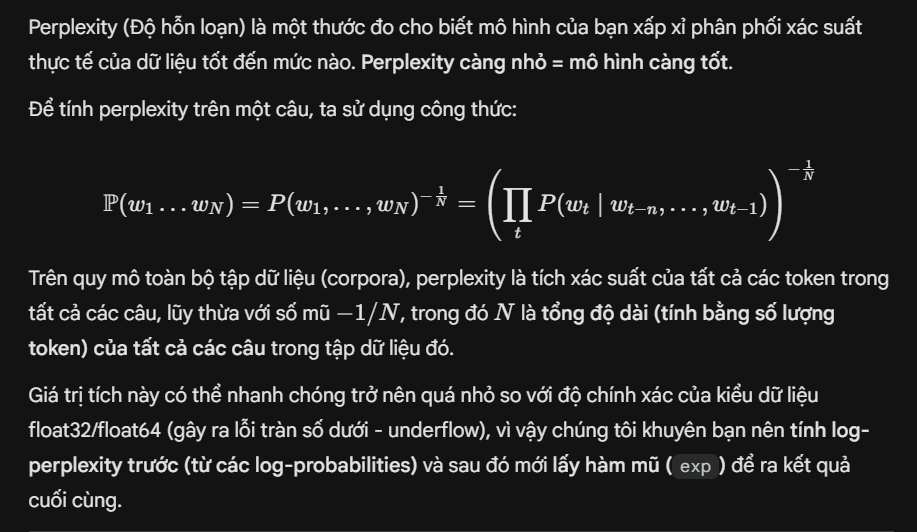

Ý tưởng:

Nếu model dự đoán đúng các từ trong tập test với xác suất cao → Perplexity thấp → Model tốt.

Nếu model thường xuyên gán xác suất thấp → Perplexity cao → Model kém.

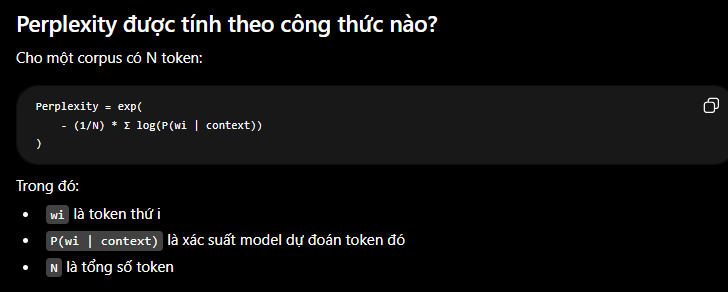

In [21]:
import numpy as np

def perplexity(lm, lines, min_logprob=np.log(10 ** -50.)):
    """
    :param lines: a list of strings with space-separated tokens
    :param min_logprob: if log(P(w | ...)) is smaller than min_logprob, set it equal to min_logprob
    :returns: corpora-level perplexity - a single scalar number from the formula above
    
    Note: do not forget to compute P(w_first | empty) and P(eos | full_sequence)
    
    PLEASE USE lm.get_next_token_prob and NOT lm.get_possible_next_tokens
    """
    total_log_prob = 0.0
    total_tokens = 0
    
    for line in lines:
        # Tách dòng thành các token dựa trên khoảng trắng
        tokens = line.split()
        
        # BÍ QUYẾT Ở ĐÂY: Sử dụng đúng token _EOS_ mà hàm count_ngrams của bài tập quy định
        tokens_with_eos = tokens + ['_EOS_']
        
        # Duyệt qua từng token (bao gồm cả _EOS_ ở cuối)
        for i, token in enumerate(tokens_with_eos):
            # Khi i=0, prefix sẽ là một chuỗi rỗng "" (Đúng chuẩn P(w_first | empty))
            prefix = " ".join(tokens_with_eos[:i])
            
            # Lấy xác suất
            prob = lm.get_next_token_prob(prefix, token)
            
            # Tính log_prob an toàn
            log_prob = np.log(prob) if prob > 0 else float('-inf')
            log_prob = max(log_prob, min_logprob)
            
            # Cộng dồn
            total_log_prob += log_prob
            total_tokens += 1

    if total_tokens == 0:
        return 1.0
        
    # Tính log-perplexity theo công thức: -1/N * Tổng_Log
    log_perplexity = - (total_log_prob / total_tokens)
    
    # Trả về Perplexity thật
    return np.exp(log_perplexity)

In [22]:
lm1 = NGramLanguageModel(dummy_lines, n=1)
lm3 = NGramLanguageModel(dummy_lines, n=3)
lm10 = NGramLanguageModel(dummy_lines, n=10)

ppx1 = perplexity(lm1, dummy_lines)
ppx3 = perplexity(lm3, dummy_lines)
ppx10 = perplexity(lm10, dummy_lines)
ppx_missing = perplexity(lm3, ['the jabberwock , with eyes of flame , '])  # thanks, L. Carrol

print("Perplexities: ppx1=%.3f ppx3=%.3f ppx10=%.3f" % (ppx1, ppx3, ppx10))

assert all(0 < ppx < 500 for ppx in (ppx1, ppx3, ppx10)), "perplexity should be non-negative and reasonably small"
assert ppx1 > ppx3 > ppx10, "higher N models should overfit and "
assert np.isfinite(ppx_missing) and ppx_missing > 10 ** 6, "missing words should have large but finite perplexity. " \
    " Make sure you use min_logprob right"
assert np.allclose([ppx1, ppx3, ppx10], (318.2132342216302, 1.5199996213739575, 1.1838145037901249))

Perplexities: ppx1=318.213 ppx3=1.520 ppx10=1.184


Now let's measure the actual perplexity: we'll split the data into train and test and score model on test data only.

In [23]:
from sklearn.model_selection import train_test_split
train_lines, test_lines = train_test_split(lines, test_size=0.25, random_state=42)

for n in (1, 2, 3):
    lm = NGramLanguageModel(n=n, lines=train_lines)
    ppx = perplexity(lm, test_lines)
    print("N = %i, Perplexity = %.5f" % (n, ppx))


N = 1, Perplexity = 1832.23136
N = 2, Perplexity = 85653987.28774
N = 3, Perplexity = 61999196259043346743296.00000


In [ ]:
# whoops, it just blew up :)

### LM Smoothing

The problem with our simple language model is that whenever it encounters an n-gram it has never seen before, it assigns it with the probabilitiy of 0. Every time this happens, perplexity explodes.

To battle this issue, there's a technique called __smoothing__. The core idea is to modify counts in a way that prevents probabilities from getting too low. The simplest algorithm here is Additive smoothing (aka [Lapace smoothing](https://en.wikipedia.org/wiki/Additive_smoothing)):

$$ P(w_t | prefix) = { Count(prefix, w_t) + \delta \over \sum_{\hat w} (Count(prefix, \hat w) + \delta) } $$

If counts for a given prefix are low, additive smoothing will adjust probabilities to a more uniform distribution. Not that the summation in the denominator goes over _all words in the vocabulary_.

Here's an example code we've implemented for you:

In [29]:
class LaplaceLanguageModel(NGramLanguageModel): 
    """ this code is an example, no need to change anything """
    def __init__(self, lines, n, delta=1.0):
        self.n = n
        counts = count_ngrams(lines, self.n)
        self.vocab = set(token for token_counts in counts.values() for token in token_counts)
        self.probs = defaultdict(Counter)

        for prefix in counts:
            token_counts = counts[prefix]
            total_count = sum(token_counts.values()) + delta * len(self.vocab)
            self.probs[prefix] = {token: (token_counts[token] + delta) / total_count
                                          for token in token_counts}
    def get_possible_next_tokens(self, prefix):
        token_probs = super().get_possible_next_tokens(prefix)
        missing_prob_total = 1.0 - sum(token_probs.values())
        missing_prob = missing_prob_total / max(1, len(self.vocab) - len(token_probs))
        return {token: token_probs.get(token, missing_prob) for token in self.vocab}
    
    def get_next_token_prob(self, prefix, next_token):
        token_probs = super().get_possible_next_tokens(prefix)
        if next_token in token_probs:
            return token_probs[next_token]
        else:
            missing_prob_total = 1.0 - sum(token_probs.values())
            missing_prob_total = max(0, missing_prob_total) # prevent rounding errors
            return missing_prob_total / max(1, len(self.vocab) - len(token_probs))
        

**Disclaimer**: the implementation above assumes all words unknown within a given context to be equally likely, *as well as the words outside of vocabulary*. Therefore, its' perplexity will be lower than it should when encountering such words. Therefore, comparing it with a model with fewer unknown words will not be fair. When implementing your own smoothing, you may handle this by adding a virtual `UNK` token of non-zero probability. Technically, this will result in a model where probabilities do not add up to $1$, but it is close enough for a practice excercise.

In [25]:
#test that it's a valid probability model
for n in (1, 2, 3):
    dummy_lm = LaplaceLanguageModel(dummy_lines, n=n)
    assert np.allclose(sum([dummy_lm.get_next_token_prob('a', w_i) for w_i in dummy_lm.vocab]), 1), "I told you not to break anything! :)"

In [28]:
for n in (1, 2, 3):
    lm = LaplaceLanguageModel(train_lines, n=n, delta=0.1)
    ppx = perplexity(lm, test_lines)
    print("N = %i, Perplexity = %.5f" % (n, ppx))

N = 1, Perplexity = 977.67559
N = 2, Perplexity = 470.48021
N = 3, Perplexity = 3679.44765


In [ ]:
# optional: try to sample tokens from such a model

### Kneser-Ney smoothing (2 points)

Additive smoothing is simple, reasonably good but definitely not a State of The Art algorithm.


Your final task in this notebook is to implement [Kneser-Ney](https://en.wikipedia.org/wiki/Kneser%E2%80%93Ney_smoothing) smoothing.

It can be computed recurrently, for n>1:

$$P_{kn}(w_t | prefix_{n-1}) = { \max(0, Count(prefix_{n-1}, w_t) - \delta) \over \sum_{\hat w} Count(prefix_{n-1}, \hat w)} + \lambda_{prefix_{n-1}} \cdot P_{kn}(w_t | prefix_{n-2})$$

where
- $prefix_{n-1}$ is a tuple of {n-1} previous tokens
- $lambda_{prefix_{n-1}}$ is a normalization constant chosen so that probabilities add up to 1
- Unigram $P_{kn}(w_t | prefix_{n-2})$ corresponds to Kneser Ney smoothing for {N-1}-gram language model.
- Unigram $P_{kn}(w_t)$ is a special case: how likely it is to see x_t in an unfamiliar context

See lecture slides or wiki for more detailed formulae.

__Your task__ is to
- implement `KneserNeyLanguageModel` class,
- test it on 1-3 gram language models
- find optimal (within reason) smoothing delta for 3-gram language model with Kneser-Ney smoothing

In [41]:
from collections import defaultdict, Counter

class KneserNeyLanguageModel(NGramLanguageModel): 
    """ Kneser-Ney language model optimized for robust backoff and exact counts. """
    def __init__(self, lines, n, delta=0.75):
        self.n = n
        self.delta = delta
        
        # Cố gắng khởi tạo lớp cha nếu có logic cần thiết
        try:
            super().__init__(lines, n)
        except Exception:
            pass
            
        self.vocab = set()
        self.counts = defaultdict(Counter)
        self.context_totals = defaultdict(int)
        self.word_preceders = defaultdict(set)
        
        # 1. Thu thập Từ vựng và Tần suất cho MỌI cấp độ Prefix (từ 0 đến n-1)
        for line in lines:
            tokens = line.split() if isinstance(line, str) else line
            self.vocab.update(tokens)
            
            for i in range(len(tokens)):
                # Gom các từ đứng trước để tính Continuation Probability
                if i > 0:
                    self.word_preceders[tokens[i]].add(tokens[i-1])
                
                # Trượt cửa sổ k từ 0 đến n-1 để lưu count cho mọi Order (Unigram, Bigram...)
                for k in range(min(self.n, i + 1)):
                    pref = tuple(tokens[i - k : i])
                    self.counts[pref][tokens[i]] += 1
                    self.context_totals[pref] += 1
                    
        self.vocab_size = max(1, len(self.vocab))
        
        # 2. TÍNH UNIGRAM CONTINUATION PROBABILITIES (Cho Backoff Base Case)
        self.total_bigram_types = sum(len(preds) for preds in self.word_preceders.values())
        self.total_bigram_types = max(1, self.total_bigram_types)
        
        self.unigram_cont_probs = {}
        num_words_with_continuation = sum(1 for w in self.vocab if len(self.word_preceders.get(w, set())) > 0)
        
        for word in self.vocab:
            cont_count = len(self.word_preceders.get(word, set()))
            # Làm mịn Absolute Discounting cho Unigram Continuation
            first_term = max(0.0, cont_count - self.delta) / self.total_bigram_types
            lam = (self.delta / self.total_bigram_types) * num_words_with_continuation
            # Backoff cuối cùng về 1/|V| (Uniform) để chắc chắn KHÔNG token nào dính xác suất 0
            self.unigram_cont_probs[word] = first_term + lam * (1.0 / self.vocab_size)
            
    def get_possible_next_tokens(self, prefix):
        return list(self.vocab)
        
    def get_next_token_prob(self, prefix, next_token):
        if isinstance(prefix, str):
            prefix = prefix.split()
        
        prefix = tuple(prefix)
        if len(prefix) > self.n - 1:
            prefix = prefix[-(self.n - 1):]
            
        return self._calculate_prob(prefix, next_token)
        
    def _calculate_prob(self, prefix, next_token):
        # Trường hợp A: Nếu người dùng yêu cầu mô hình N=1 ngay từ đầu
        # Ta dùng Tần suất thực (Actual Counts), không dùng Continuation.
        if self.n == 1 and len(prefix) == 0:
            count_unigram = self.counts[()][next_token]
            total_unigrams = self.context_totals[()]
            if total_unigrams == 0:
                return 1.0 / self.vocab_size
            
            first = max(0.0, count_unigram - self.delta) / total_unigrams
            lam = (self.delta / total_unigrams) * len(self.counts[()])
            return first + lam * (1.0 / self.vocab_size)
            
        # Trường hợp B: Đáy của chuỗi đệ quy Backoff (Prefix đã bị cắt gọt xuống N=0)
        # Bắt buộc phải dùng Unigram Continuation theo lý thuyết Kneser-Ney
        if len(prefix) == 0:
            return self.unigram_cont_probs.get(next_token, 1.0 / self.vocab_size)
            
        # Trường hợp C: Công thức Kneser-Ney tiêu chuẩn cho N-gram (N >= 2)
        count_prefix_wt = self.counts[prefix][next_token]
        total_prefix = self.context_totals[prefix]
        
        if total_prefix == 0:
            # Ngữ cảnh hoàn toàn mới -> Lùi 100% về mô hình bậc thấp hơn
            return self._calculate_prob(prefix[1:], next_token)
            
        first_term = max(0.0, count_prefix_wt - self.delta) / total_prefix
        
        num_unique_continuations = len(self.counts[prefix])
        lam = (self.delta / total_prefix) * num_unique_continuations
        
        backoff_prob = self._calculate_prob(prefix[1:], next_token)
        
        return first_term + lam * backoff_prob

In [43]:
#test that it's a valid probability model
for n in (1, 2, 3):
    dummy_lm = KneserNeyLanguageModel(dummy_lines, n=n)
    assert np.allclose(sum([dummy_lm.get_next_token_prob('a', w_i) for w_i in dummy_lm.vocab]), 1), "I told you not to break anything! :)"

In [44]:
for n in (1, 2, 3):
    # Bạn có thể điều chỉnh giá trị `delta` (smoothing) ở đây để tìm mốc tối ưu (thường là 0.75 hoặc 1.0)
    lm = KneserNeyLanguageModel(train_lines, n=n, delta=0.75)
    ppx = perplexity(lm, test_lines)
    print("N = %i, Perplexity = %.5f" % (n, ppx))

KeyboardInterrupt: 

Perplexity có thể hiểu gần đúng là:

"Ở mỗi bước model đang phân vân giữa bao nhiêu lựa chọn."

| Perplexity | Ý nghĩa trực quan         |
| ---------- | ------------------------- |
| 1          | Chắc chắn hoàn toàn       |
| 2          | Phân vân giữa 2 từ        |
| 10         | Phân vân giữa 10 từ       |
| 100        | Rất khó đoán              |
| 1000+      | Gần như không học được gì |
